# 📘 Functions, Scoping and Abstractions

## 🎬 Introduction
> With just **numbers**, **assignments**, **input/output**, **comparisons**, and **loops**, you can solve **any problem** that can be solved by a computer.

Even without:
- Functions
- Classes
- Modules
- Recursion
- Lambdas
- Libraries

You still have something **Turing complete** — i.e., you already have enough building blocks to compute anything *computable*.

### 🧮 Turing Machine

Named after Alan Turing, a system is **Turing complete** if:

- It can simulate a **Turing Machine** (a mathematical model of computation).
- It can perform **arbitrary computations**, given enough time and memory.



A Turing machine is a theoretical device that:
- Has an infinite tape (memory),
- Can read/write symbols,
- Can make decisions based on conditions,
- Can loop indefinitely.



### 🧩 Why functions ?

Let us see the code for a square root using bisection search below

In [10]:
x = int(input("Enter an integer: "))
epsilon = 0.01
num_guesses = 1
low = 0
high = max(1.0, x)
ans = (high + low) / 2.0
while abs(ans**2 - x) >= epsilon:
    print(f'low:{low}, high:{high}, ans:{ans}, guess:{num_guesses}')
    if ans**2 > x:
        high = ans 
    else:
        low = ans
    ans = (high+low)/2
    num_guesses += 1

### 🚨 Issues
#### 🧩 Limitations of Hardcoded Computation

This is a reasonable piece of code, but it **lacks general utility**.

- It works only for the specific values assigned to the variables `x` and `epsilon`.
- To reuse it:
  - We would need to **copy the code**, possibly **edit the variable names**, and paste it where needed.
  - This is repetitive and error-prone.

---

#### ⚠️ Not Easily Reusable

We **cannot easily use this computation** inside another, more complex computation.
- For example, embedding this logic inside a larger function or reusing it in multiple places becomes difficult.

---

#### 🔁 Redundant Code

If we want to:
- Compute **cube roots** instead of square roots → we have to **edit the code**.
- Compute square roots in **two different places** → the program would contain **multiple chunks of almost identical code**.

This violates the **DRY principle** (Don't Repeat Yourself) and leads to:
- Code duplication
- Harder maintenance
- More chances of introducing bugs

---

💡 **Solution:** Use a function!  
Functions help abstract away the logic and allow reusability, flexibility, and cleaner code.

## 📚 What are functions ?
* **Reusable Code Blocks:** Functions encapsulate blocks of code for repeated use.
* **Modularity:** They break down large programs into smaller, manageable parts.
* **Abstraction:** Functions hide implementation details, focusing on what they do.
* **Inputs and Outputs:**
    * Functions can accept **parameters** (inputs).
    * They can return **values** (outputs) using the `return` statement.
* **Definition:**
    * Defined using the `def` keyword.
    * Indented code block follows the function definition.
* **Benefits:**
    * Code reusability.
    * Improved readability.
    * Better organization.
    * Easier debugging.

## 🔑 Key Terminologies

* **Function** is a block of code that performs a specific task.
* **Function Declaration** is a statement that defines a function.
* **Function Call** is a statement that executes a function.
* **Function Definition** is a statement that defines the code that the function executes.
* **Function Prototype** is a statement that declares the function's name, return type, and parameters.
* **Function Parameters** are variables that are passed to a function.
* **Function Arguments** are values that are passed to a function.
* **Return Type** is the data type of the value that a function returns.
* **Return Statement** is a statement that returns a value from a function.
* **Void Function** is a function that does not return a value.
* **Value-Returning Function** is a function that returns a value.
* **Function Overloading** is the ability to define multiple functions with the same name but different parameters.
* **Function Recursion** is the ability of a function to call itself.



In [ ]:
def find_root(x, power, epsilon):
    if x < 0 and power % 2 == 0:
        return None
    low = min(x,-1)
    high = max(1,x)
    ans = (low + high)/2
    while abs(ans**power - x) >= epsilon:
        if ans**power < x:
            low = ans 
        else:
            high = ans
        ans = (low + high)/2
    return ans

In [50]:
def test_find(x_vals, powers, epsilons):
    for x in x_vals:
        for power in powers:
            for epsilon in epsilons:
                result = find_root(x,power,epsilon)
                if result == None:
                    val = "No root exists"
                else:
                    val = result
                print(f'x = {x}, power = {power}, epsilon = {epsilon}, result =  {val}')
                
x_vals = (0.25, 8, -8)
powers = (1, 2, 3)
epsilon = (0.1,0.01,1)
test_find(x_vals, powers, epsilon)              

x = 0.25, power = 1, epsilon = 0.1, result =  0.25
x = 0.25, power = 1, epsilon = 0.01, result =  0.25
x = 0.25, power = 1, epsilon = 1, result =  0.0
x = 0.25, power = 2, epsilon = 0.1, result =  0.5
x = 0.25, power = 2, epsilon = 0.01, result =  0.5
x = 0.25, power = 2, epsilon = 1, result =  0.0
x = 0.25, power = 3, epsilon = 0.1, result =  0.625
x = 0.25, power = 3, epsilon = 0.01, result =  0.625
x = 0.25, power = 3, epsilon = 1, result =  0.0
x = 8, power = 1, epsilon = 0.1, result =  7.9296875
x = 8, power = 1, epsilon = 0.01, result =  7.9912109375
x = 8, power = 1, epsilon = 1, result =  7.4375
x = 8, power = 2, epsilon = 0.1, result =  2.83203125
x = 8, power = 2, epsilon = 0.01, result =  2.82763671875
x = 8, power = 2, epsilon = 1, result =  2.9375
x = 8, power = 3, epsilon = 0.1, result =  2.005859375
x = 8, power = 3, epsilon = 0.01, result =  1.999267578125
x = 8, power = 3, epsilon = 1, result =  1.953125
x = -8, power = 1, epsilon = 0.1, result =  -7.9296875
x = -8, po

### 🌀 Positional and Keyword Arguments in Python

In Python, there are two ways that formal parameters get bound to actual parameters:

1. **Positional arguments**: The first formal parameter is bound to the first actual parameter, the second to the second, etc.
2. **Keyword arguments**: Formal parameters are bound to actual values using the name of the formal parameter.

In [52]:
def print_name(first_name, last_name, reverse):
    if reverse:
        print(last_name + ', ' + first_name)
    else:
        print(first_name, last_name)

#### 🧪 Example Calls with Equivalent Meaning

In [56]:
print_name('Olga', 'Puchmajerova', False)
print_name('Olga', 'Puchmajerova', reverse=False)
print_name('Olga', last_name='Puchmajerova', reverse=False)
print_name(last_name='Puchmajerova', first_name='Olga', reverse=False)

Olga Puchmajerova
Olga Puchmajerova
Olga Puchmajerova
Olga Puchmajerova


#### 🐞 Invalid Use Case: Wrong Order Positional Arguments

In [ ]:
print_name(False, 'Olga','Puchmajerova')

#### 🐞 Invalid Use Case: Mixing Positional After Keyword

In [55]:
print_name('Olga', last_name='Puchmajerova', False)  # This will raise a SyntaxError

SyntaxError: positional argument follows keyword argument (1219784392.py, line 1)

#### 🧪 Using Default Parameter Values

In [ ]:
def print_name(first_name, last_name, reverse=False):
    if reverse:
        print(last_name + ', ' + first_name)
    else:
        print(first_name, last_name)

#### 🧪 Calls with Default and Keyword Arguments

In [ ]:
print_name('Olga', 'Puchmajerova')
print_name('Olga', 'Puchmajerova', True)
print_name('Olga', 'Puchmajerova', reverse=True)

Using keyword arguments provides clarity and prevents mistakes related to argument ordering.

### 🌀 Variable Number of Arguments 

Python has a number of built-in functions that operate on a **variable number of arguments**.

For example:

```python
min(6, 4)         # returns 4
min(3, 4, 1, 6)   # returns 1
```

#### 🛠️ Defining Your Own Functions with Variable Arguments

Python makes it easy to write functions that accept a variable number of positional arguments using the unpacking operator `*`

**📌 Example : Computing the Mean**

In [ ]:
def mean(*args):
    # Assumes at least one argument and all arguments are numbers
    # Returns the mean of the arguments
    tot = 0
    for a in args:
        tot += a
    return tot / len(args)

**🤔 What is happening ?**
* The `*args` syntax allows the function to accept any number of positional arguments.
* Inside the function, `args` is treated as a tuple of all the arguments passed.

**📝 Notes** 
* The name after `*` doesn’t have to be `args`. It can be any valid variable name.
* For example, a more descriptive version of mean might be:

In [61]:
def mean(*numbers):
    tot = 0
    for n in numbers:
        tot += n
    return tot / len(numbers)

## 🚀 Scoping
### 🎬 Introduction to Scoping

In [65]:
def f(x): #name x used as formal parameter
    y = 1
    x = x + y
    print('x =', x)
    return x
x = 3
y = 2
z = f(x) #value of x used as actual parameter
print('z =', z)
print('x =', x)
print('y =', y)

x = 4
z = 4
x = 3
y = 2


**🤔 What is happening ?**

When f(x) is called:
* The formal parameter `x` inside `f` is bound locally to the value of the actual argument `x`, which is `3`.
* Even though the names are the same, the variables are different. They live in different scopes.

**🔑 Key Concepts:**
* Each function defines a new scope (namespace).
* The variables `x` and `y` inside `f` exist only within the function’s scope.
* The assignment `x = x + y` inside `f` modifies the local `x`, not the global one.
* The `print('x =', x)` inside `f` prints the local `x`, which is `4`.
* After the function ends, the global `x` and `y` remain unchanged.
* Scoping determines how variables are accessed.
* It's like rules for finding the "right box" (variable).
* Two main types: **Static** and **Dynamic**.
* Local scope: Variables defined within a function.
* Enclosing scope: The scope of the outer function containing the inner function.
* Global scope: Variables defined outside any function.

### 🌀 Static Scoping (Python)

* Scope determined by code structure (lexical).
* Determined at compile time.

### 🌀 Dynamic Scoping
* Scope determined by call stack (runtime).
* Depends on the calling sequence.


In [1]:
x = 10
def outer():
    x = 20
    def inner():
        print("Inside Inner (Python):", x)
    inner()
    standalone()

def standalone():
    print("Inside Standalone (Python):", x)

outer()
standalone()

Inside Inner (Python): 20
Inside Standalone (Python): 10
Inside Standalone (Python): 10


In [2]:
%%bash
#!/bin/bash
x=10
function outer {
  local x=20
  inner
  standalone
}
function inner {
  echo "Inside Inner (Bash): $x"
}
function standalone {
  echo "Inside Standalone (Bash): $x"
}
outer

Inside Inner (Bash): 20
Inside Standalone (Bash): 20


### 🔑 Key Differences
* Python (Static): Definition location matters.
* Bash (Dynamic): Call location matters.
* Static: Predictable, easier to debug.
* Dynamic: Runtime customizations, but harder to reason about.


## 🚀 Stack Frames 

### 📘 Introduction

When a function is called in a program, a dedicated section of memory is allocated to manage that function's execution. This memory area is known as a **stack frame** or an **activation record**. Stack frames are crucial for managing function calls, local variables, and return addresses.

Imagine a stack of plates. Each plate represents a function call. When a function is called, a new plate (stack frame) is placed on top of the stack. When the function finishes executing, its plate is removed from the top. This "last-in, first-out" (LIFO) behavior is fundamental to how stack frames operate.


---

### ❓ What is a Stack Frame?

Each stack frame typically contains:

* **Local Variables:** Variables declared within the function's scope.
* **Parameters:** Input values passed to the function.
* **Return Address:** The memory address of the instruction to return to after the function finishes.
* **Saved Registers:** Values of CPU registers that need to be preserved.
* **Previous Frame Pointer (Optional):** A pointer to the previous stack frame, used for stack unwinding and debugging.

**Function Execution:**

* The function executes its instructions, using the local variables and parameters stored in its stack frame.
* When the function encounters a return statement, it retrieves the return address from its stack frame.
* The function cleans up its stack frame, restoring saved registers, and jumps to the return address.

**Stack Unwinding:**

* When a function returns, its stack frame is popped off the stack.
* The program resumes execution at the return address.
* If an exception occurs, the stack may be unwound to find an appropriate exception handler.
---

In [3]:
def f(x):
    def g():
        x = 'abc'
        print('x =', x)
    def h():
        z = x
        print('z =', z)
    x = x + 1
    print('x =', x)
    h()
    g()
    print('x =', x)
    return g
x = 3
z = f(x)
print('x =', x)
print('z =', z)
z()

x = 4
z = 4
x = abc
x = 4
x = 3
z = <function f.<locals>.g at 0x1049f5120>
x = abc


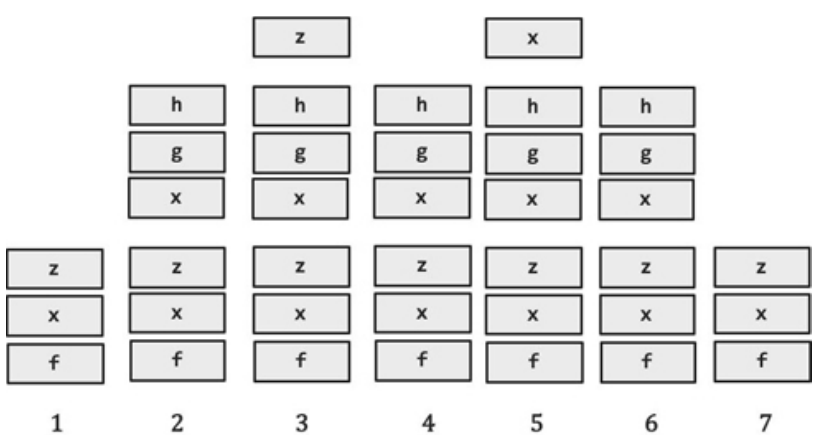

### 🐍 Common Issue: Not Defined

In [ ]:
def f(x):
    def g():
        print(x)
g()

### 🐍 Common Issue: UnboundLocalError

In [7]:
def f():
    print(x)
def g():
    print(x)
    x = 1
x = 3
f()
g()

3


UnboundLocalError: cannot access local variable 'x' where it is not associated with a value

**Why does this happen**

* In the inner function python assumes a new local variable as it is defined but definition is after the `x` is called 

### 🐍 Common Issue: UnboundLocalError

In [6]:
def f(x):
    def g():
        x = x + 1  # This will cause an UnboundLocalError
        print("x =", x)
    return g

x = 3
z = f(x)
z()  # Causes an error

UnboundLocalError: cannot access local variable 'x' where it is not associated with a value

**Why does this happen?**
- Python assumes `x` inside `g` is a new local variable.
- Since `x` is used before being assigned, it raises an error.

### 🐍🔧 Fix: Using `nonlocal`

In [ ]:
def f(x):
    def g():
        nonlocal x  # Tell Python to use x from f's scope
        x = x + 1
        print("x =", x)
    return g

x = 3
z = f(x)
z()  # Works correctly

**Key Fix:**
- `nonlocal x` tells Python to modify `x` from `f` instead of creating a new local variable.

### 🧠 The `nonlocal` Keyword

- Used to modify variables in the nearest enclosing (non-global) scope.
- Allows inner functions to change variables from outer functions.
- Prevents creation of new local variables with the same name.

## 🚀 Closures

### ❓ What is a Closure?

A **closure** in Python is a function that:

- Is defined inside another function (**nested function**),
- Remembers variables from its **enclosing scope**, even after the outer function has finished executing.

This allows the inner function to "remember" and use the variables from the outer function even when it’s called **later** or **elsewhere**.

### 🤔 How Does It Work?

When you define a function inside another function:

- Python stores the **environment** (variables) of the outer function along with the inner function.
- This environment is kept alive as long as the inner function is accessible.

### 🧪 Basic Example

In [ ]:
def outer():
    x = 10
    def inner():
        print(x)  # x is remembered from outer
    return inner

fn = outer()
fn()  # prints: 10

### 🤷‍♀️ Why Use Closures?

Closures can be used for:
- 1️⃣ **Encapsulation** without using classes : Encapsulation means hiding internal details and exposing only what’s necessary—like how a class hides internal data and exposes methods. In object-oriented programming, we typically do this using classes. But in Python, closures can also give you encapsulation without using a class.

- 2️⃣ Creating **function factories** : A function factory is a function that creates and returns other functions — like a factory that makes customized tools

- 3️⃣ Maintaining **state** in a function across multiple calls : Normally, when you call a function, it runs → does its thing → returns → forgets everything. But sometimes you want a function to “remember” some data between calls — like keeping a count, storing a cache, or tracking history.

### 🎯 Real-Life Analogy

Imagine a **toolbox** (`inner function`) that remembers the **tools** (`variables`) it got from the **factory** (`outer function`). Even if the factory shuts down, the toolbox still has what it needs to work.

### ⚠️ Common Gotcha: Late Binding

When you create closures inside a loop, all the returned inner functions share the same variable — and that variable is looked up only when the function is called, not when it’s defined.

In [9]:
def make_multipliers():
    funcs = []
    for i in range(3):
        def multiplier(x):
            return i * x
        funcs.append(multiplier)
    return funcs

f1, f2, f3 = make_multipliers()
print(f1(2), f2(2), f3(2))  # All return 4, not 0, 2, 4!

4 4 4


**🤔 What’s Happening?**

* Python closures capture variables by reference, not by value.
* When you call f1(), it looks up i — but the loop has already finished, and i is now 2.
* So all functions use the latest value of i.

### 🐍🔧 Fix using default args (binding values early)

In [ ]:
def make_multipliers():
    funcs = []
    for i in range(3):
        def multiplier(x, i=i):  # bind i at definition time
            return i * x
        funcs.append(multiplier)
    return funcs

f1, f2, f3 = make_multipliers()
print(f1(2), f2(2), f3(2))  # Correct: 0, 2, 4

### 🔁 Closures + State (Counter Example)

In [ ]:
def counter():
    count = 0
    def increment():
        nonlocal count
        count += 1
        return count
    return increment

c = counter()
print(c())  # 1
print(c())  # 2
print(c())  # 3

## 📄 Function Specification

### 🔗 What is a Function Specification?

A **function specification** defines a **contract** between:
- The **implementer** of a function, and
- The **clients** (users) who will use the function in their code.

This contract has **two main parts**:

---

#### 🧾 1. Assumptions (Preconditions)

These describe the **requirements that must be met by the client** of the function before it is called.

Examples include:
- Expected **data types** for arguments
- Valid **value ranges** for parameters
- Any other **constraints** that must hold before execution

🧠 For example:  
A `find_root` function might assume that `power` is a **positive integer**.

---

#### 🛡️ 2. Guarantees (Postconditions)

These describe what the function **promises to deliver**, **provided the assumptions are met**.

Examples include:
- The function will return a correct result
- Or return `None` if a result doesn't exist

🧠 For example:  
`find_root` might guarantee returning `None` if asked to compute the **square root of a negative number**.

---

### 🧱 Functions as Primitives

Functions help define **computational primitives** and support two core software principles:

#### 🧩 Decomposition

- Breaks a large problem into **smaller, reusable parts**
- Improves **code structure and modularity**

#### 🎭 Abstraction

- Hides unnecessary **details**
- Allows clients to use functions as **black boxes**
- Focuses only on what's **relevant** to the current context

> The **essence of abstraction**: Preserve relevant information, forget the irrelevant.

---

### 🐍 Python Docstrings as Specifications

Python uses docstrings to specify what a function does:

In [1]:
def abs(x):
    """
    Returns the absolute value of the argument.
    """

In [2]:
help(abs)

Help on function abs in module __main__:

abs(x)
    Returns the absolute value of the argument.



## 📚 Use Function to Modularize the Code

In [9]:
def find_root_bounds(x,power):
    '''x - a float, power - a positive integer
    return low, high such that low**power < = x 
    and high**power>=x'''
    low = min(x,-1)
    high = max(1,x)
    return low, high
def bisection_solve(x,power,epsilon,low,high):
    ans = (low+high)/2
    while abs(ans**power - x) >= epsilon:
        if ans**power < x :
            low = ans 
        else:
            high = ans 
        ans = (low+high)/2
    return ans

def find_root(x, power, epsilon):
    '''x - a float, power - a positive integer'''
    if x < 0 and power % 2 == 0:
        return None
    low, high = find_root_bounds(x,power)
    ans = bisection_solve(x,power,epsilon,low,high)
    return ans

## 🌀 Functions as First-Class Objects

In Python, functions possess a unique characteristic: they are considered **first-class objects**. This implies that they can be manipulated and treated in a manner analogous to objects of other data types like integers or lists.

### 🔑Key Properties of First-Class Functions:

1️⃣ **Type:** Functions have a type. 

In [2]:
print(type(abs))
print(type(find_root))

<class 'builtin_function_or_method'>
<class 'function'>


2️⃣ **Assignment:** Functions can be assigned to variables, just like any other value.

In [3]:
def greet(name):
        return f"Hello, {name}!"

my_function = greet
print(my_function("Alice"))

Hello, Alice!


3️⃣ **Arguments:** Functions can be passed as arguments to other functions. This enables powerful techniques like higher-order functions.


In [4]:
def apply_operation(func, x, y):
    return func(x, y)

def add(a, b):
    return a + b

result = apply_operation(add, 5, 3)
print(result) 

8


🧪 **Writing bisection solve to be generic** 

In [10]:
def bisection_solve(x, eval_func, epsilon, low, high):
    ans = (low + high) / 2
    while abs(eval_func(ans) - x) >= epsilon:
        if eval_func(ans) < x:
            low = ans
        else:
            high = ans
        ans = (low + high) / 2
    return ans

**🤔 What is happening ?**

* `eval_func` is a function that maps floats to float

*  replaced every instance of `ans**power` with `eval_func(ans)`

* For finding the square root of 99 :

In [ ]:
def square(x):
    return x ** 2
low,high = find_root_bounds(99,2)
print(bisection_solve(99, square, 0.01, low, high))

9.94970703125


4️⃣ **Return Values:** Functions can return other functions. This is crucial for creating function factories and closures.

In [ ]:
def multiplier(n):
    def inner(x):
        return x * n
    return inner
double = multiplier(2)
triple = multiplier(3)
print(double(5))  
print(triple(5))  

10
15


5️⃣ **Data Structures:** Functions can be stored in data structures like lists or dictionaries

In [14]:
operations = {
        "add": lambda a, b: a + b,
        "subtract": lambda a, b: a - b,
    }

print(operations["add"](10, 5))

15


### 📚 Lambda Functions


#### ❓ What is a Lambda Function?

A **lambda function** is a small, anonymous function in Python that is defined using the `lambda` keyword instead of `def`.

They are often used for **short, simple operations** — especially when passing a function as an argument.

---

#### 🎯 Syntax

```python
lambda arguments: expression

* lambda is the keyword
* arguments is a comma-separated list of input parameters
* expression is a single expression (no statements or blocks)


In [ ]:
square = lambda x: x ** 2
print(square(5)) 

exponential = lambda x, y: x ** y
print(exponential(2, 3))

In [ ]:
functions = [lambda x: x + n for n in range(3)]
print([f(10) for f in functions])

#### 🧪 Common Use Cases

🔹 1. With `map()`

In [ ]:
nums = [1, 2, 3, 4]
squared = list(map(lambda x: x ** 2, nums))
print(squared) 

🔹 2. With `filter()`

In [ ]:
nums = [1, 2, 3, 4, 5]
evens = list(filter(lambda x: x % 2 == 0, nums))
print(evens) 

🔹 3. With `sorted()` and `key=`

In [ ]:
pairs = [(1, 3), (2, 2), (4, 1)]
sorted_pairs = sorted(pairs, key=lambda x: x[1])
print(sorted_pairs) 

#### 📝 When to Use **Lambda**

Use lambda when:
* The function is simple and short
* You’re using it as an argument to another function
* Defining it with def would feel unnecessarily verbose

Avoid lambda when:
* The logic is complex
* You need to reuse the function elsewhere
* Readability is important